<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Atom_Beam_Lithography_Sim_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# GPU Monte Carlo atom-beam and matter-wave lithography

This notebook predicts an illustrative ThinkPad-style exposure pattern through a thin transmission mask, comparing a geometric beam model with coherent Fresnel propagation followed by incoherent source averaging. Run the installation cell in Google Colab with a CUDA GPU selected, then run the simulation cell. CuPy accelerates FFT propagation, Gaussian convolution, Poisson sampling, and response calculations; the same implementation runs with NumPy if no GPU is available.

You can set `MASK_IMAGE_PATH` to an uploaded grayscale transmission image for a specific design. White transmits, black blocks, and grayscale specifies fractional **intensity** transmission. Transparent PNGs should first be flattened onto a black background. The imported design is scaled to fit the stated field, so its physical size is controlled by `FIELD_WIDTH_UM`.

## Primer and physical scope

A neutral-atom beam is also a matter wave. The two branches below are approximations for the same beam, not unrelated lithography technologies. The geometric limit propagates the transmitted fluence without diffraction; the wave branch retains coherent diffraction within each incident mode. Different incident velocities and angles are treated as mutually incoherent source modes.

| Stage | Direct physical effect | Implementation and limitation |
|---|---|---|
| Thin mask | Modulates transmitted amplitude | Amplitude is the square root of intensity transmission; no membrane thickness or atom-wall forces |
| Longitudinal speed | Sets de Broglie wavelength | Independent lognormal velocity draws, parameterized by arithmetic mean and relative standard deviation |
| Free propagation | Produces Fresnel diffraction | Padded FFT transfer function; periodic computational boundary must remain distant |
| Angular divergence | Shifts each coherent diffraction pattern | Exact Gaussian intensity convolution for independent Gaussian paraxial angles |
| Atom arrivals | Produce shot noise | Independent Poisson counts with mean equal to local fluence times pixel area |
| Surface response spread | Redistributes deposited excitation locally | Assumed Gaussian kernel applied after atom arrivals, distinct from beam divergence |
| Material damage | Converts exposure into an illustrative patterned region | Assumed Hill response followed by a threshold; no calibrated development or etch kinetics |

For mass $m$ and longitudinal velocity $v$, the de Broglie wavelength is

$$\lambda(v)=\frac{h}{mv}.$$

For a normally incident plane-wave mode and intensity transmission $T(x,y)$, the propagated field at mask-substrate gap $z$ is

$$\psi_v(x,y;z)=\mathcal F^{-1}\!\left[\mathcal F\{\sqrt{T}\}\exp\{-i\pi\lambda(v)z(f_x^2+f_y^2)\}\right].$$

Here $f_x,f_y$ are spatial frequencies in cycles per metre. A small incident angle translates the propagated intensity by $z\boldsymbol\theta$. Gaussian angle averaging therefore directly gives a Gaussian convolution with width $\sigma_b=z\sigma_\theta$. The Monte Carlo velocity average is

$$\bar I=\frac{1}{M}\sum_{j=1}^{M}G_{\sigma_b}*|\psi_{v_j}|^2.$$

The geometric counterpart is $I_g=G_{\sigma_b}*T$. Both branches retain absolute transmission throughput and use the same unmasked incident fluence $D_0$. With background fraction $b$ and pixel area $A$, physical arrival counts obey

$$N_{ij}\sim\mathrm{Poisson}\!\left[D_0(\bar I_{ij}+b)A\right].$$

The response dose is $D=G_{\sigma_s}*(N/A)$, where $\sigma_s$ is an assumed surface-response spreading width. The illustrative damage fraction is

$$R(D)=\frac{(D/D_{50})^\gamma}{1+(D/D_{50})^\gamma}.$$

A pixel belongs to the predicted exposed region when $R(D)\ge R_{\mathrm{threshold}}$. Whether this region becomes removed resist, retained material, or an etched opening depends on the actual fabrication process. This is metastable-helium **resist exposure**.

## Default physical scenario

| Control | Default | Meaning |
|---|---:|---|
| Field width | 12 µm | Full computational region shown, with wordmark fitted inside |
| Grid | 1024 × 384 | Square pixels, approximately 11.7 nm across |
| Atomic mass | 4.002602 u | Helium-4 illustrative beam |
| Mean speed | 1000 m/s | Approximately 99.7 pm de Broglie wavelength |
| Relative speed spread | 8% | Assumed longitudinal source distribution |
| Mask-substrate gap | 50 µm | Approximately 71 nm Fresnel length $\sqrt{\lambda z}$ |
| Angular spread | 0.30 mrad per axis | Approximately 15 nm geometric blur |
| Incident fluence | 30 atoms/nm² | $3\times10^{15}$ atoms/cm² |
| Surface-response spread | 8 nm | Assumed, not measured for a specified resist |
| Damage midpoint | 17 atoms/nm² | Illustrative parameter only |
| Hill exponent | 6 | Assumed dose-response steepness |
| Velocity draws | 48 | Independent integration samples |
| Exposure replicates | 24 | Physical shot-noise repeatability samples |

NIST reports substantial damage near $1.7(3)\times10^{15}$ atoms/cm² for metastable helium in a particular self-assembled-monolayer resist experiment [2]. This equals $17\pm3$ atoms/nm², but **a substantial-damage threshold is not a measured 50% damage midpoint**. The default midpoint borrows that order of magnitude; its mapping to the Hill curve is an explicit modeling assumption. Replace it and the response exponent with measured dose-response data before interpreting the result as a process prediction.

Independent sampling is preferable to Metropolis here because the source distribution and arrival law are directly sampleable. A Metropolis or simulated-annealing extension would be useful for inverse mask design, where an acceptance objective trades image error against fabrication constraints; it is not needed for this forward calculation.

In [ ]:
!pip -q install uv
!uv pip install --system numpy scipy matplotlib pillow cupy-cuda12x

In [2]:
"""Verify CUDA FFT, kernel compilation and random sampling before simulation."""
import cupy as cp

if cp.cuda.runtime.getDeviceCount() < 1:
    raise RuntimeError("Select a runtime with an NVIDIA GPU before continuing.")
probe = cp.arange(64, dtype=cp.float64).reshape(8, 8)
roundtrip = cp.fft.ifft2(cp.fft.fft2(probe)).real
if not bool(cp.allclose(probe, roundtrip).item()):
    raise ArithmeticError("CUDA FFT round-trip verification failed.")
cp.random.RandomState(27).poisson(cp.ones(8)).sum().item()
cp.cuda.get_current_stream().synchronize()
print(f"GPU verification passed. CuPy {cp.__version__}, device {cp.cuda.Device().id}.")
del probe, roundtrip

GPU verification passed. CuPy 14.0.1, device 0.


GPU verification passed. CuPy 14.0.1, device 0.
Velocity modes submitted: 12/48
Velocity modes submitted: 24/48
Velocity modes submitted: 36/48
Velocity modes submitted: 48/48
Completed 24 exposures: Geometric atom beam
Completed 24 exposures: Matter-wave beam


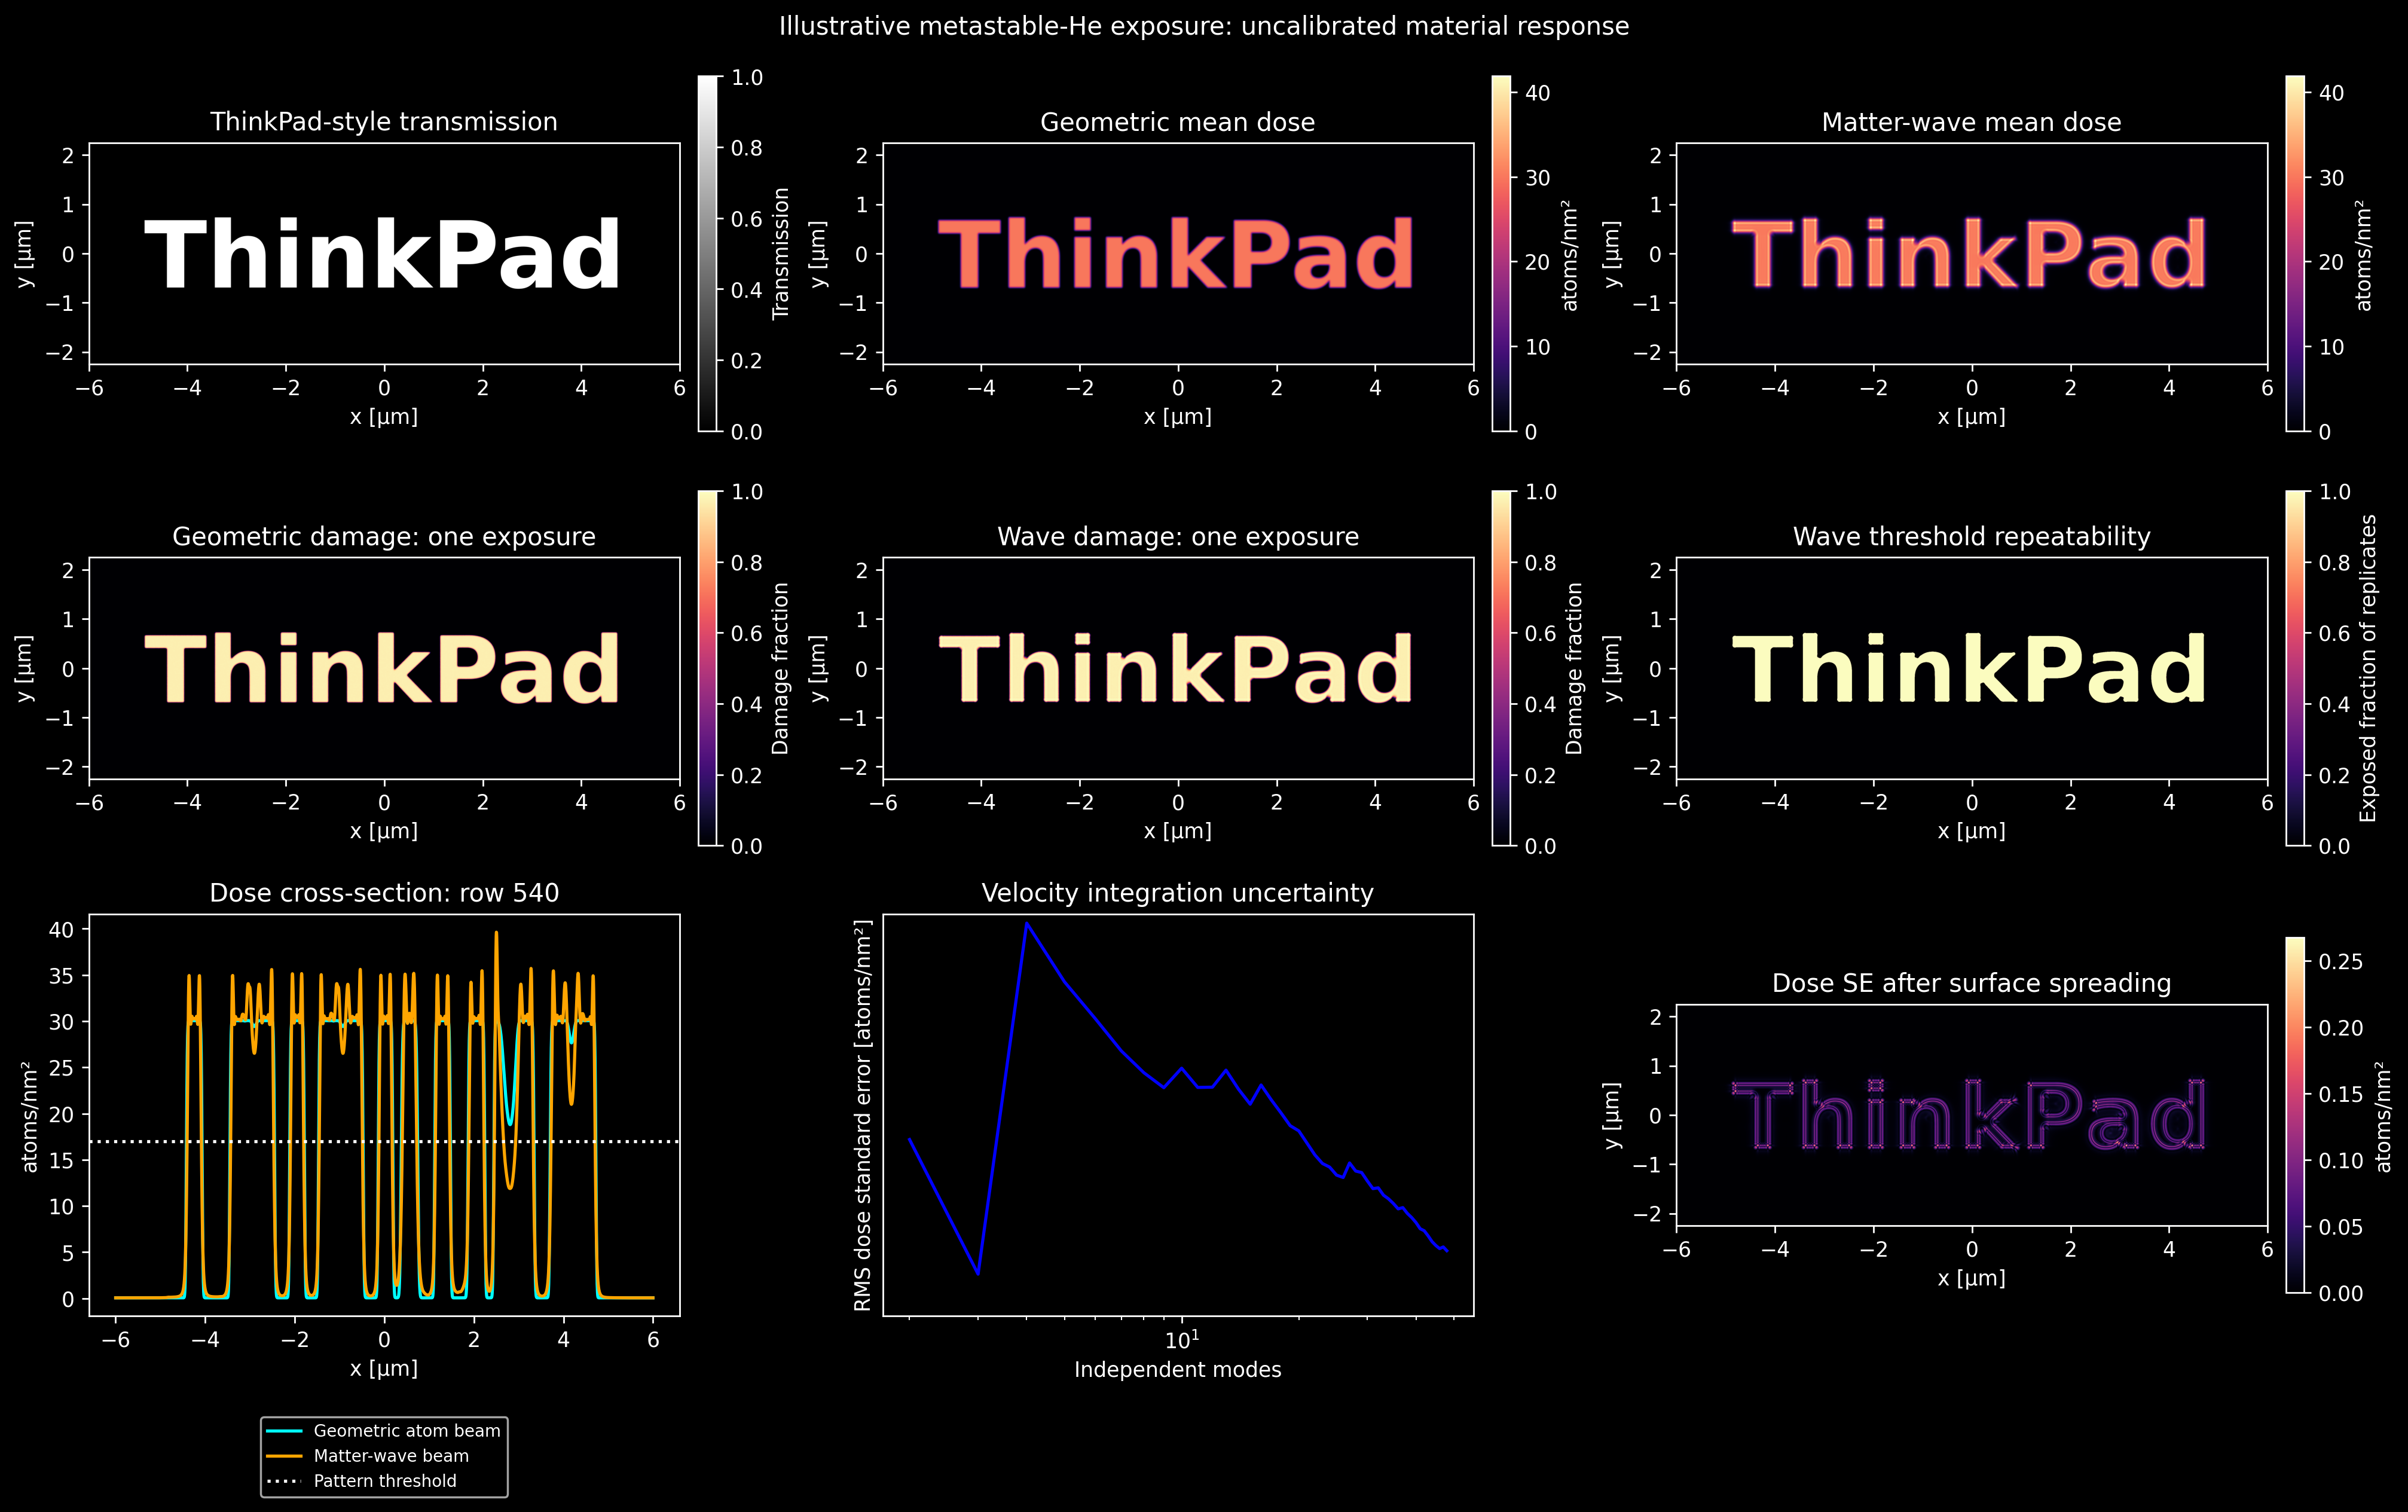

{
  "backend": "cupy",
  "precision": "float64",
  "pixel_nm": 3.90625,
  "mean_wavelength_pm": 101.08075526787317,
  "angular_blur_nm": 14.999999999999998,
  "surface_blur_pixels": 2.048,
  "fresnel_scale_nm": 71.09175594535317,
  "velocity_modes": 48,
  "shot_replicates": 24,
  "crop_flux_capture_geometric_wave": [
    1.0000000000000002,
    0.9999999736518219
  ],
  "max_periodic_domain_flux_error": 4.440892098500626e-16,
  "max_blurred_flux_error": 4.440892098500626e-16,
  "flux_tolerance": 1e-10,
  "elapsed_seconds": 15.519573478999973,
  "model_status": "Illustrative response; calibration required",
  "gpu_pool_used_MiB_at_return": 1299.76171875,
  "gpu_pool_reserved_MiB_at_return": 2407.2265625
}
Geometric atom beam: mean IoU=0.97923; replicate 2.5–97.5% range=[0.97912, 0.97933]
Matter-wave beam: mean IoU=0.88013; replicate 2.5–97.5% range=[0.88002, 0.88024]
IoU measures image overlap, not fabrication success probability.
Replicate ranges include arrival noise only; MC SE cover

In [3]:
"""Simulate thin-mask atomic exposure and matter-wave diffraction on a GPU.

Use independent Monte Carlo velocity samples and Poisson atom arrivals.
The material response is illustrative and requires experimental calibration.
The default wordmark is a typographic surrogate for ThinkPad artwork.

CuPy installation must match the runtime CUDA environment. CPU execution uses
SciPy FFTs with NumPy arrays. PRECISION selects field and convolution precision;
Monte Carlo moments and conservation reductions use float64 in both modes.
The returned PNG is rendered in memory. No files are written automatically.
"""
import io
import json
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager
from PIL import Image, ImageDraw, ImageFont, ImageOps
from scipy import fft as scipy_fft

# - Control knobs: computation and reproducibility -
BACKEND = "auto"  # "auto", "cupy" (requires GPU), or "numpy".
SEED = 27
NX, NY = 3072, 1152
PAD_FACTOR = 2
VELOCITY_SAMPLES = 48
SHOT_REPLICATES = 24
PRECISION = "float64"  # "float32" reduces array memory; verify convergence.
SHOW_PROGRESS = True
PROGRESS_EVERY = 12
SHOW_FIGURE = True

# - Control knobs: geometry and beam -
FIELD_WIDTH_UM = 12.0
MASK_IMAGE_PATH = None
LOGO_ROTATION_DEG = 0.0
MASS_U = 4.002602
MEAN_SPEED_M_S = 1000.0
RELATIVE_SPEED_STD = 0.08
MASK_GAP_UM = 50.0
ANGLE_STD_MRAD = 0.30
SURFACE_RESPONSE_SIGMA_NM = 8.0
INCIDENT_DOSE_ATOMS_NM2 = 30.0
BACKGROUND_FRACTION = 0.002

# - Control knobs: illustrative material response and plots -
DAMAGE_D50_ATOMS_NM2 = 17.0
DAMAGE_HILL_EXPONENT = 6.0
PATTERN_DAMAGE_THRESHOLD = 0.5
REQUIRE_CROP_CAPTURE = 0.995
FIGURE_DPI = 250

plt.rcParams.update({"figure.dpi": FIGURE_DPI, "savefig.dpi": FIGURE_DPI})

def validate_settings():
    """Reject invalid settings before allocating arrays."""
    for name, value, minimum in (
        ("NX", NX, 32), ("NY", NY, 32), ("PAD_FACTOR", PAD_FACTOR, 2),
        ("VELOCITY_SAMPLES", VELOCITY_SAMPLES, 2),
        ("SHOT_REPLICATES", SHOT_REPLICATES, 2),
        ("PROGRESS_EVERY", PROGRESS_EVERY, 1),
    ):
        if isinstance(value, (bool, np.bool_)) or not isinstance(
            value, (int, np.integer)
        ):
            raise ValueError(f"{name} must be an integer.")
        if value < minimum:
            raise ValueError(f"{name} must be at least {minimum}.")

    if PRECISION not in {"float32", "float64"}:
        raise ValueError("PRECISION must be float32 or float64.")
    if not isinstance(SEED, (int, np.integer)) or not 0 <= SEED < 2**32:
        raise ValueError("SEED must be an integer in [0, 2**32).")
    if not np.isfinite(LOGO_ROTATION_DEG):
        raise ValueError("LOGO_ROTATION_DEG must be finite.")
    positive = (
        FIELD_WIDTH_UM, MASS_U, MEAN_SPEED_M_S, DAMAGE_D50_ATOMS_NM2,
        DAMAGE_HILL_EXPONENT, FIGURE_DPI,
    )
    nonnegative = (
        MASK_GAP_UM, ANGLE_STD_MRAD, RELATIVE_SPEED_STD,
        SURFACE_RESPONSE_SIGMA_NM, INCIDENT_DOSE_ATOMS_NM2,
        BACKGROUND_FRACTION,
    )

    if not all(np.isfinite(v) and v > 0 for v in positive):
        raise ValueError(
            "Lengths, mass, speed, response constants and DPI must be positive."
        )
    if not all(np.isfinite(v) and v >= 0 for v in nonnegative):
        raise ValueError("Gap, spreads, dose and background must be nonnegative.")
    if not 0 < PATTERN_DAMAGE_THRESHOLD < 1:
        raise ValueError("PATTERN_DAMAGE_THRESHOLD must lie in (0, 1).")
    if not 0 < REQUIRE_CROP_CAPTURE <= 1:
        raise ValueError("REQUIRE_CROP_CAPTURE must lie in (0, 1].")

def select_backend():
    """Select a backend; permit fallback only during GPU initialization."""
    if BACKEND not in {"auto", "numpy", "cupy"}:
        raise ValueError("BACKEND must be auto, numpy, or cupy.")

    if BACKEND != "numpy":
        try:
            import cupy as cp
            if cp.cuda.runtime.getDeviceCount() < 1:
                raise RuntimeError("No CUDA device detected.")

            # Exercise every CUDA primitive needed by the calculation.
            dtype = getattr(cp, PRECISION)
            probe = cp.arange(64, dtype=dtype).reshape(8, 8)
            tolerance = 2e-5 if PRECISION == "float32" else 1e-11
            roundtrip = cp.fft.ifft2(cp.fft.fft2(probe)).real
            real_roundtrip = cp.fft.irfft2(cp.fft.rfft2(probe), s=probe.shape)
            for restored in (roundtrip, real_roundtrip):
                if not bool(cp.allclose(probe, restored, atol=tolerance)):
                    raise ArithmeticError("CUDA FFT round-trip failed.")
            draws = cp.random.RandomState(SEED).poisson(probe + 1)
            response = cp.exp(-cp.logaddexp(0.0, -cp.log(probe + 1)))
            if not bool(cp.all(cp.isfinite(response))) or draws.shape != probe.shape:
                raise ArithmeticError("CUDA response or Poisson probe failed.")
            cp.cuda.get_current_stream().synchronize()

            print(
                f"GPU verification passed. CuPy {cp.__version__}, "
                f"device {cp.cuda.Device().id}."
            )
            return cp
        except Exception as exc:
            if BACKEND == "cupy":
                raise RuntimeError(f"GPU initialization failed: {exc}") from exc
            warnings.warn(f"CUDA unavailable; using NumPy: {exc}", stacklevel=2)

    return np

def make_mask():
    """Rasterize a typographic surrogate or fit a grayscale transmission image."""
    if MASK_IMAGE_PATH is not None:
        with Image.open(MASK_IMAGE_PATH) as source:
            rgba = ImageOps.exif_transpose(source).convert("RGBA")
            background = Image.new("RGBA", rgba.size, (0, 0, 0, 255))
            img = Image.alpha_composite(background, rgba).convert("L")
    else:
        try:
            font_path = font_manager.findfont(
                font_manager.FontProperties(family="DejaVu Sans", weight="bold")
            )
        except ValueError:
            font_path = font_manager.findfont(
                font_manager.FontProperties(family="sans-serif", weight="bold")
            )

        scale = NX / 1024
        font = ImageFont.truetype(font_path, max(1, round(240 * scale)))
        margin = max(1, round(20 * scale))
        left, top, right, bottom = font.getbbox("ThinkPad")
        img = Image.new("L", (right - left + 2 * margin, bottom - top + 2 * margin))
        ImageDraw.Draw(img).text(
            (margin - left, margin - top), "ThinkPad", font=font, fill=255
        )

    if LOGO_ROTATION_DEG:
        img = img.rotate(
            LOGO_ROTATION_DEG, resample=Image.Resampling.BICUBIC, expand=True
        )

    fit = min(NX * 0.84 / img.width, NY * 0.64 / img.height)
    img = img.resize(
        (max(1, int(img.width * fit)), max(1, int(img.height * fit))),
        Image.Resampling.LANCZOS,
    )
    canvas = Image.new("L", (NX, NY))
    canvas.paste(img, ((NX - img.width) // 2, (NY - img.height) // 2))
    mask = np.asarray(canvas, dtype=np.float64) / 255.0

    if not np.any(mask >= 0.5):
        raise ValueError(
            "The mask must contain a target pixel with transmission >= 0.5."
        )
    return mask

def simulate():
    """Return mean doses, shot-noise results, Monte Carlo SE and diagnostics."""
    validate_settings()
    xp = select_backend()
    fft = scipy_fft if xp is np else xp.fft
    dtype = getattr(xp, PRECISION)
    complex_dtype = xp.complex64 if PRECISION == "float32" else xp.complex128
    flux_tolerance = 5e-6 if PRECISION == "float32" else 1e-10
    started = time.perf_counter()
    host_rng = np.random.default_rng(SEED)
    seed_sequence = np.random.SeedSequence(SEED)
    shot_seeds = [int(s.generate_state(1)[0]) for s in seed_sequence.spawn(2)]

    def host(array):
        """Transfer arrays only for reporting and plotting."""
        return xp.asnumpy(array) if xp is not np else np.asarray(array)

    mask_host = make_mask()
    mask = xp.asarray(mask_host, dtype=dtype)
    target = mask >= 0.5
    dx = FIELD_WIDTH_UM * 1e-6 / NX
    area_nm2 = (dx * 1e9) ** 2
    height, width = NY * PAD_FACTOR, NX * PAD_FACTOR
    shape = (height, width)
    oy, ox = (height - NY) // 2, (width - NX) // 2
    crop = (slice(oy, oy + NY), slice(ox, ox + NX))
    transmission = xp.zeros(shape, dtype=dtype)
    transmission[crop] = mask
    source_sum = float(transmission.sum(dtype=xp.float64).item())
    gap = MASK_GAP_UM * 1e-6
    angular_sigma = gap * ANGLE_STD_MRAD * 1e-3

    # Only 1D phase factors are stored; broadcasting avoids a full f^2 grid.
    fy2 = xp.asarray(fft.fftfreq(height, d=dx) ** 2, dtype=xp.float64)
    fx2 = xp.asarray(fft.fftfreq(width, d=dx) ** 2, dtype=xp.float64)

    def gaussian_kernel(sigma):
        """Return a half-spectrum of a positive normalized discrete kernel."""
        if sigma == 0:
            return None
        iy, ix = xp.arange(height), xp.arange(width)
        y = xp.minimum(iy, height - iy) * dx
        x = xp.minimum(ix, width - ix) * dx
        gy = xp.exp(-0.5 * (y / sigma) ** 2)
        gx = xp.exp(-0.5 * (x / sigma) ** 2)
        gy = (gy / gy.sum()).astype(dtype)
        gx = (gx / gx.sum()).astype(dtype)
        return fft.fft(gy)[:, None] * fft.rfft(gx)[None, :]

    angular_transfer = gaussian_kernel(angular_sigma)
    surface_sigma = SURFACE_RESPONSE_SIGMA_NM * 1e-9
    surface_transfer = gaussian_kernel(surface_sigma)

    def from_spectrum(spectrum, kernel):
        """Convolve a real-valued field using its cached half-spectrum."""
        product = spectrum if kernel is None else spectrum * kernel
        output = fft.irfft2(product, s=shape)
        # A positive discrete kernel guarantees nonnegative exact output.
        # Clipping removes only FFT roundoff; check conserved total separately.
        xp.maximum(output, 0, out=output)
        return output

    def blur(array, kernel):
        """Bypass transforms for zero blur; otherwise use real FFTs."""
        if kernel is None:
            return array
        return from_spectrum(fft.rfft2(array), kernel)

    spectrum = fft.fft2(xp.sqrt(transmission)).astype(complex_dtype, copy=False)
    geometric_full = blur(transmission, angular_transfer)
    mean = xp.zeros(shape, dtype=dtype)
    dose_mean = xp.zeros((NY, NX), dtype=xp.float64)
    dose_m2 = xp.zeros_like(dose_mean)
    log_sigma = np.sqrt(np.log1p(RELATIVE_SPEED_STD**2))
    speeds = host_rng.lognormal(
        np.log(MEAN_SPEED_M_S) - log_sigma**2 / 2,
        log_sigma, VELOCITY_SAMPLES,
    )
    wavelengths = 6.62607015e-34 / (MASS_U * 1.66053906660e-27 * speeds)
    if not np.all(np.isfinite(wavelengths)) or np.any(wavelengths <= 0):
        raise ValueError("The sampled wavelengths must be finite and positive.")
    history_values = xp.zeros(VELOCITY_SAMPLES - 1, dtype=xp.float64)
    flux_errors = xp.zeros(VELOCITY_SAMPLES, dtype=xp.float64)
    blur_flux_errors = xp.zeros_like(flux_errors)

    for index, wavelength in enumerate(wavelengths, start=1):
        # Calculate phases in float64 before casting their unit phasors.
        phase_y = xp.exp(-1j * np.pi * wavelength * gap * fy2)
        phase_x = xp.exp(-1j * np.pi * wavelength * gap * fx2)
        propagated = spectrum * phase_y.astype(complex_dtype)[:, None]
        propagated *= phase_x.astype(complex_dtype)[None, :]
        field = fft.ifft2(propagated)
        intensity = xp.abs(field)
        intensity *= intensity
        flux_errors[index - 1] = xp.abs(
            intensity.sum(dtype=xp.float64) / source_sum - 1
        )
        del field, propagated

        # One forward real FFT supplies both beam and response convolutions.
        angular_spectrum = fft.rfft2(intensity)
        if angular_transfer is not None:
            angular_spectrum *= angular_transfer
        intensity = from_spectrum(angular_spectrum, None)
        mean += (intensity - mean) / index
        blur_flux_errors[index - 1] = xp.abs(
            intensity.sum(dtype=xp.float64) / source_sum - 1
        )
        mode_dose = from_spectrum(angular_spectrum, surface_transfer)[crop]
        mode_dose = mode_dose.astype(xp.float64) * INCIDENT_DOSE_ATOMS_NM2
        delta = mode_dose - dose_mean
        dose_mean += delta / index
        dose_m2 += delta * (mode_dose - dose_mean)
        if index > 1:
            history_values[index - 2] = xp.sqrt(
                xp.maximum(dose_m2, 0).mean() / ((index - 1) * index)
            )
        del angular_spectrum, intensity, mode_dose, delta
        if SHOW_PROGRESS and index % PROGRESS_EVERY == 0:
            print(f"Velocity modes submitted: {index}/{VELOCITY_SAMPLES}")

    # Synchronize once at the end of the velocity loop, not per scalar statistic.
    flux_error = float(flux_errors.max().item())
    blur_flux_error = float(blur_flux_errors.max().item())
    if max(flux_error, blur_flux_error) > flux_tolerance:
        raise ArithmeticError(
            f"Flux error exceeds {flux_tolerance:g}: "
            f"propagation={flux_error:.3e}, blur={blur_flux_error:.3e}"
        )
    mc_se = xp.sqrt(
        xp.maximum(dose_m2, 0) / ((VELOCITY_SAMPLES - 1) * VELOCITY_SAMPLES)
    )
    captures = [float(a[crop].sum(dtype=xp.float64).item()) / source_sum
                for a in (geometric_full, mean)]
    if min(captures) < REQUIRE_CROP_CAPTURE:
        warnings.warn(
            "Flux leaves the displayed field. Enlarge the field and verify "
            "padding convergence; conservation alone does not exclude wraparound.",
            stacklevel=2,
        )
    if max(wavelengths) / dx > 0.1:
        warnings.warn("The paraxial grid criterion needs review.", stacklevel=2)
    for name, sigma in (("Angular", angular_sigma), ("Surface", surface_sigma)):
        if 0 < sigma < dx:
            warnings.warn(
                f"{name} blur is narrower than one pixel; refine the grid.",
                stacklevel=2,
            )

    def damage(dose):
        """Evaluate the assumed Hill response without power overflow."""
        ratio = xp.maximum(dose / DAMAGE_D50_ATOMS_NM2, xp.finfo(dtype).tiny)
        log_odds = DAMAGE_HILL_EXPONENT * xp.log(ratio)
        response = xp.exp(-xp.logaddexp(0.0, -log_odds))
        return xp.where(dose > 0, response, 0)

    results = []
    models = (("Geometric atom beam", geometric_full), ("Matter-wave beam", mean))
    for model_index, (label, intensity) in enumerate(models):
        shot_rng = xp.random.RandomState(shot_seeds[model_index])
        arrival = INCIDENT_DOSE_ATOMS_NM2 * (intensity + BACKGROUND_FRACTION)
        if not bool(xp.all(xp.isfinite(arrival))):
            raise ArithmeticError("Arrival dose is not finite.")
        mean_dose = blur(arrival, surface_transfer)[crop]
        probability = xp.zeros((NY, NX), dtype=xp.float64)
        overlaps = xp.zeros(SHOT_REPLICATES, dtype=xp.float64)
        poisson_mean = arrival * area_nm2
        for rep in range(SHOT_REPLICATES):
            counts = shot_rng.poisson(poisson_mean)
            realized = counts.astype(dtype) / area_nm2
            del counts
            realized_dose = blur(realized, surface_transfer)[crop]
            response = damage(realized_dose)
            pattern = response >= PATTERN_DAMAGE_THRESHOLD
            probability += pattern
            intersection = xp.count_nonzero(pattern & target)
            union = xp.count_nonzero(pattern | target)
            overlaps[rep] = intersection / xp.maximum(union, 1)
            if rep == 0:
                sample_dose = host(realized_dose.copy())
                sample_response = host(response.copy())
            del realized, realized_dose, response, pattern
        overlaps_host = host(overlaps)
        results.append({
            "label": label,
            "dose": host(mean_dose),
            "sample_dose": sample_dose,
            "response": sample_response,
            "probability": host(probability / SHOT_REPLICATES),
            "iou": overlaps_host.tolist(),
            "iou_mean": float(overlaps_host.mean()),
            "iou_percentiles": np.quantile(overlaps_host, [0.025, 0.975]).tolist(),
        })
        del arrival, mean_dose, probability, poisson_mean
        if SHOW_PROGRESS:
            print(f"Completed {SHOT_REPLICATES} exposures: {label}")

    history = np.column_stack((np.arange(2, VELOCITY_SAMPLES + 1),
                               host(history_values)))
    if xp is not np:
        xp.cuda.get_current_stream().synchronize()
    diagnostics = {
        "backend": xp.__name__, "precision": PRECISION,
        "pixel_nm": dx * 1e9,
        "mean_wavelength_pm": float(np.mean(wavelengths) * 1e12),
        "angular_blur_nm": angular_sigma * 1e9,
        "surface_blur_pixels": surface_sigma / dx,
        "fresnel_scale_nm": float(np.sqrt(np.mean(wavelengths) * gap) * 1e9),
        "velocity_modes": VELOCITY_SAMPLES,
        "shot_replicates": SHOT_REPLICATES,
        "crop_flux_capture_geometric_wave": captures,
        "max_periodic_domain_flux_error": flux_error,
        "max_blurred_flux_error": blur_flux_error,
        "flux_tolerance": flux_tolerance,
        "elapsed_seconds": time.perf_counter() - started,
        "model_status": "Illustrative response; calibration required",
    }
    if xp is not np:
        diagnostics["gpu_pool_used_MiB_at_return"] = (
            xp.get_default_memory_pool().used_bytes() / 2**20
        )
        diagnostics["gpu_pool_reserved_MiB_at_return"] = (
            xp.get_default_memory_pool().total_bytes() / 2**20
        )
    return mask_host, results, host(mc_se), history, diagnostics


def visualize(mask, results, mc_se, history, diagnostics):
    """Render dose, response and uncertainty; return a 250-DPI PNG buffer."""
    half_height = FIELD_WIDTH_UM * NY / NX / 2
    extent = [-FIELD_WIDTH_UM / 2, FIELD_WIDTH_UM / 2, -half_height, half_height]
    dose_max = max(float(r["dose"].max()) for r in results) or 1.0
    with plt.style.context("dark_background"):
        fig, axes = plt.subplots(3, 3, figsize=(16, 10), layout="constrained")
        panels = [
            (mask, "ThinkPad-style transmission", "gray", 1, "Transmission"),
            (results[0]["dose"], "Geometric mean dose", "magma", dose_max,
             "atoms/nm²"),
            (results[1]["dose"], "Matter-wave mean dose", "magma", dose_max,
             "atoms/nm²"),
            (results[0]["response"], "Geometric damage: one exposure", "magma",
             1, "Damage fraction"),
            (results[1]["response"], "Wave damage: one exposure", "magma",
             1, "Damage fraction"),
            (results[1]["probability"], "Wave threshold repeatability", "magma",
             1, "Exposed fraction of replicates"),
        ]
        for ax, (data, title, cmap, vmax, label) in zip(axes.flat, panels):
            im = ax.imshow(data, origin="upper", extent=extent,
                           cmap=cmap, vmin=0, vmax=vmax)
            ax.set(title=title, xlabel="x [µm]", ylabel="y [µm]")
            fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label=label)

        row = int(np.argmax(mask.sum(axis=1)))
        x = extent[0] + (np.arange(NX) + 0.5) * FIELD_WIDTH_UM / NX
        ax = axes[2, 0]
        for result, color in zip(results, ("cyan", "orange")):
            ax.plot(x, result["dose"][row], color=color, label=result["label"])
        # Convert the selected damage threshold into its dose threshold.
        ratio = PATTERN_DAMAGE_THRESHOLD / (1 - PATTERN_DAMAGE_THRESHOLD)
        dose_threshold = DAMAGE_D50_ATOMS_NM2 * ratio**(1 / DAMAGE_HILL_EXPONENT)
        ax.axhline(dose_threshold, color="white", ls=":", label="Pattern threshold")
        ax.set(title=f"Dose cross-section: row {row}", xlabel="x [µm]",
               ylabel="atoms/nm²")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.23),
                  fontsize=8, ncol=1)
        ax = axes[2, 1]
        ax.plot(history[:, 0], history[:, 1], color="#0000ff")
        ax.set_xscale("log")
        if np.any(history[:, 1] > 0):
            ax.set_yscale("symlog", linthresh=1e-12)
        ax.set(title="Velocity integration uncertainty", xlabel="Independent modes",
               ylabel="RMS dose standard error [atoms/nm²]")
        ax = axes[2, 2]
        im = ax.imshow(mc_se, extent=extent, origin="upper", cmap="magma", vmin=0)
        ax.set(title="Dose SE after surface spreading", xlabel="x [µm]",
               ylabel="y [µm]")
        fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="atoms/nm²")
        fig.suptitle(
            "Illustrative metastable-He exposure: uncalibrated material response"
        )
        buffer = io.BytesIO()
        fig.savefig(buffer, format="png", dpi=FIGURE_DPI)
        buffer.seek(0)
        if SHOW_FIGURE:
            plt.show()
        plt.close(fig)
    print(json.dumps(diagnostics, indent=2))
    for result in results:
        low, high = result["iou_percentiles"]
        print(f'{result["label"]}: mean IoU={result["iou_mean"]:.5f}; '
              f'replicate 2.5–97.5% range=[{low:.5f}, {high:.5f}]')
    print("IoU measures image overlap, not fabrication success probability.")
    print(
        "Replicate ranges include arrival noise only; "
        "MC SE covers velocity integration."
    )
    print("Neither measure includes material calibration or grid/padding uncertainty.")
    return buffer


if __name__ == "__main__":
    mask, results, mc_se, history, diagnostics = simulate()
    figure_buffer = visualize(mask, results, mc_se, history, diagnostics)